# Integrated EDA — KT mobility × NIMS contact × ILI

## Project
수도권(서울/경기/인천) 행정동 단위 시·공간 감염 시뮬레이션을 위한 통합 데이터셋.
본 노트북은 5개 정제 데이터(인구, mobility, contact, calendar, ILI)의 핵심 시각화와 통계를
한 자리에서 보여준다. 다음 프로젝트(`kt_epimodel`)의 reference로 사용.

## Datasets (5종)
- **Population**: 주민등록 5세 → NIMS 15군 (수도권 1,148 행정동)
- **Mobility**: KT 통신 데이터, 행정동 OD × 시간 × 7 연령군
- **Contact**: NIMS 설문 4 settings × 15군 ([contact, participant])
- **Calendar**: 학사·공휴일 → 4 daytype
- **ILI**: 질병청 5절기 주별 (ISO 36주~다음해 35주, calibration target)

## Caveats
- KT 0–9세는 검출률 0.15 → 정적 모델 / mobility 미사용
- NIMS contact 절대 magnitude는 과소 추정 가능 → β로 흡수 예정
- ILI 시도별/연령별 데이터 미공개 (전국 평균만)

In [1]:
import os
import sys
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# Resolve project root so loaders find data/... regardless of where the kernel starts.
_HERE = Path.cwd()
PROJECT_ROOT = _HERE.parent if _HERE.name == "notebooks" else _HERE
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_population import load_population_15groups, get_population_matrix, AGE_LABELS_15
from src.data.load_mobility import load_mobility
from src.data.load_contact import load_contact_matrices, get_contact_matrix
from src.data.load_calendar import classify_date, get_daytype_for_range
from src.data.load_ili import load_ili_seasons

OUT_DIR = PROJECT_ROOT / "outputs" / "integrated_eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.dpi"] = 120
print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR:     ", OUT_DIR)

PROJECT_ROOT: /Users/hwcho/Documents/python/NIMS/KT_data
OUT_DIR:      /Users/hwcho/Documents/python/NIMS/KT_data/outputs/integrated_eda


## 1. Population — 주민등록 NIMS 15군

- 출처: 행정안전부 주민등록 인구 (2023년 1월)
- 연령: NIMS 15군 (5세 단위, 70+ 통합)
- 지역: 수도권 (서울/경기/인천) 1,148 행정동

행정동 수: 1,154
총 인구:   25,990,466



/var/folders/p6/bh0h2f651z556fbmr892wdl80000gn/T/ipykernel_19640/852362353.py:38: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p6/bh0h2f651z556fbmr892wdl80000gn/T/ipykernel_19640/852362353.py:38: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p6/bh0h2f651z556fbmr892wdl80000gn/T/ipykernel_19640/852362353.py:38: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p6/bh0h2f651z556fbmr892wdl80000gn/T/ipykernel_19640/852362353.py:38: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p6/bh0h2f651z556fbmr892wdl80000gn/T/ipykernel_19640/852362353.py:38: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p6/bh0h2f651z556fbmr892wdl80000gn/T/ipykernel_1

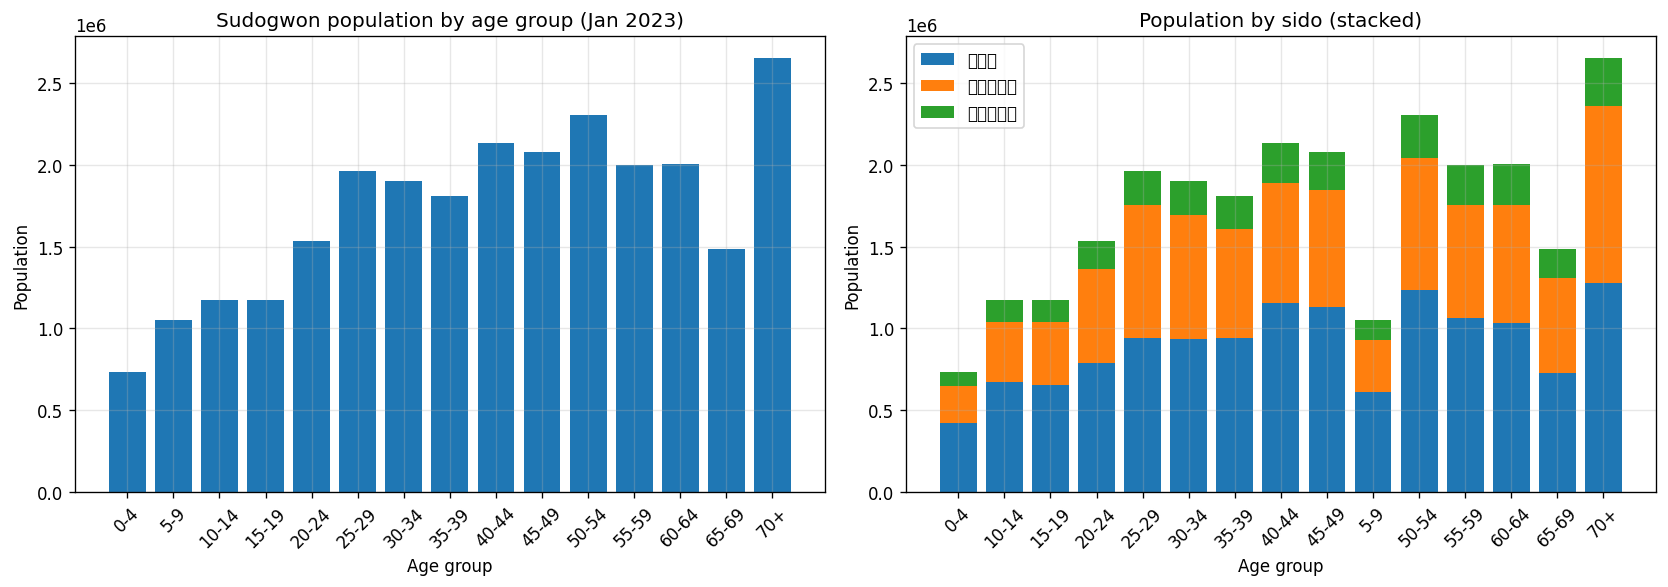

In [2]:
df_pop = load_population_15groups()
print(f"행정동 수: {df_pop['admdong_cd'].n_unique():,}")
print(f"총 인구:   {df_pop['pop'].sum():,}")
print()

age_dist = df_pop.group_by(["age_group", "age_idx"]).agg(pl.col("pop").sum()).sort("age_idx")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(age_dist["age_group"], age_dist["pop"])
axes[0].set_xlabel("Age group")
axes[0].set_ylabel("Population")
axes[0].set_title("Sudogwon population by age group (Jan 2023)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3)

sido_age = (
    df_pop.group_by(["sido_nm", "age_group", "age_idx"])
    .agg(pl.col("pop").sum())
    .sort(["sido_nm", "age_idx"])
)
pivot = sido_age.pivot(values="pop", index="age_group", on="sido_nm").sort("age_group")
ages = pivot["age_group"].to_list()
sidos = [c for c in pivot.columns if c != "age_group"]

bottom = np.zeros(len(ages))
for sido in sidos:
    vals = pivot[sido].to_numpy()
    axes[1].bar(ages, vals, bottom=bottom, label=sido)
    bottom += vals
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Population")
axes[1].set_title("Population by sido (stacked)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "01_population.png", dpi=120)
plt.show()

## 2. KT Mobility

- 출처: KT 통신 데이터 (수도권 250m 그리드 → 행정동 집계)
- 연령: KT 10세 단위 — 우리 모델에서는 0–9 제외, 70/80 합산 = 7군
- 검출률 가정 (잠정, Phase 4 보정 예정):
  - 0–9세: 0.15 (정적 모델로 처리, mobility 미사용)
  - 20–69세: ~0.9 (적극 활용)
  - 70+: 0.55 (보정 필요)

Shape:    (1154, 1154, 7, 24)
평일 일수: 20
total:    29,681,360


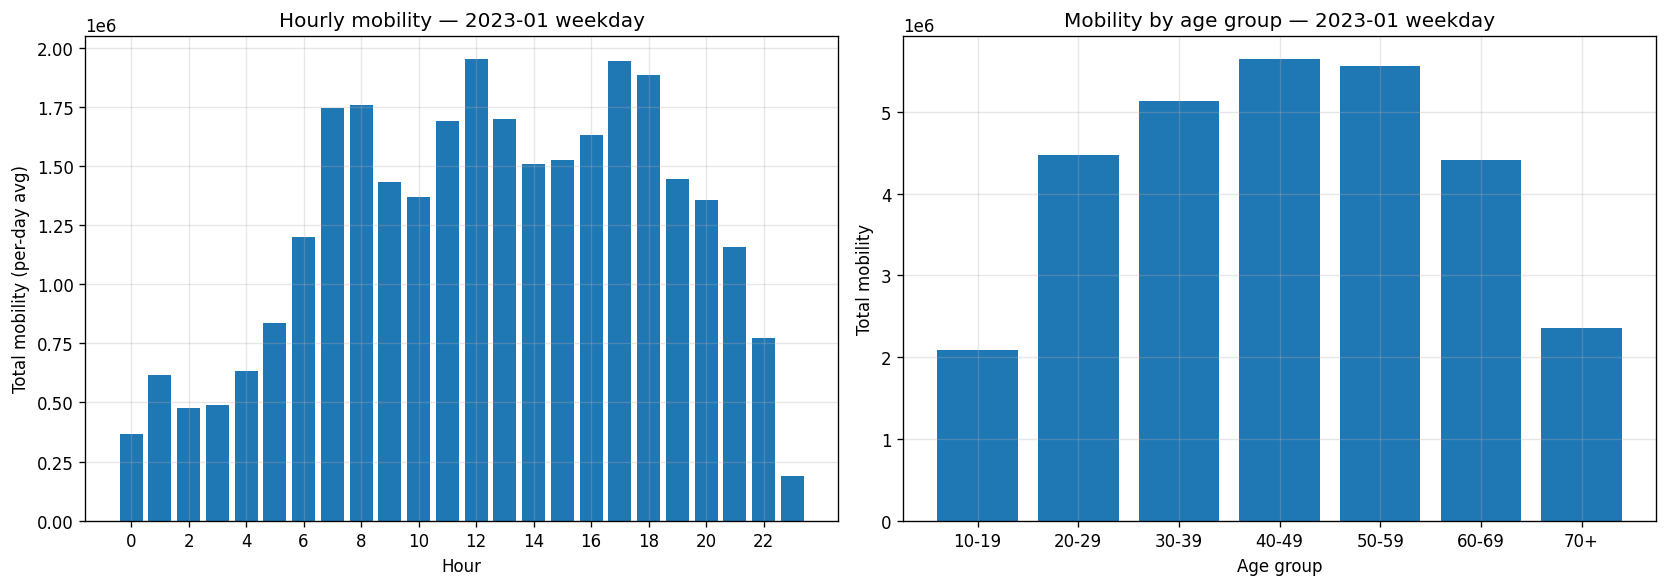

In [4]:
result = load_mobility("202301", daytype="weekday")
pi = result["pi"]
print(f"Shape:    {pi.shape}")
print(f"평일 일수: {result['n_days']}")
print(f"total:    {pi.sum():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly = pi.sum(axis=(0, 1, 2))
axes[0].bar(range(24), hourly)
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Total mobility (per-day avg)")
axes[0].set_title("Hourly mobility — 2023-01 weekday")
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)

age_labels_mob = ["10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70+"]
age_sums = pi.sum(axis=(0, 1, 3))
axes[1].bar(age_labels_mob, age_sums)
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Total mobility")
axes[1].set_title("Mobility by age group — 2023-01 weekday")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "02_mobility.png", dpi=120)
plt.show()

## 3. NIMS Contact Matrix

- 출처: NIMS 설문 (2023-12, 2024-2)
- 연령: 15군 (5세 단위, 70+ 통합)
- 4 settings: `home / work / school / other`
- 컨벤션: `[contact, participant]` (좌하단 0–4, 우상단 70+; `origin='lower'`)
- 한계: NIMS 측정 절대값 과소 추정 가능 → β scaling으로 흡수 예정

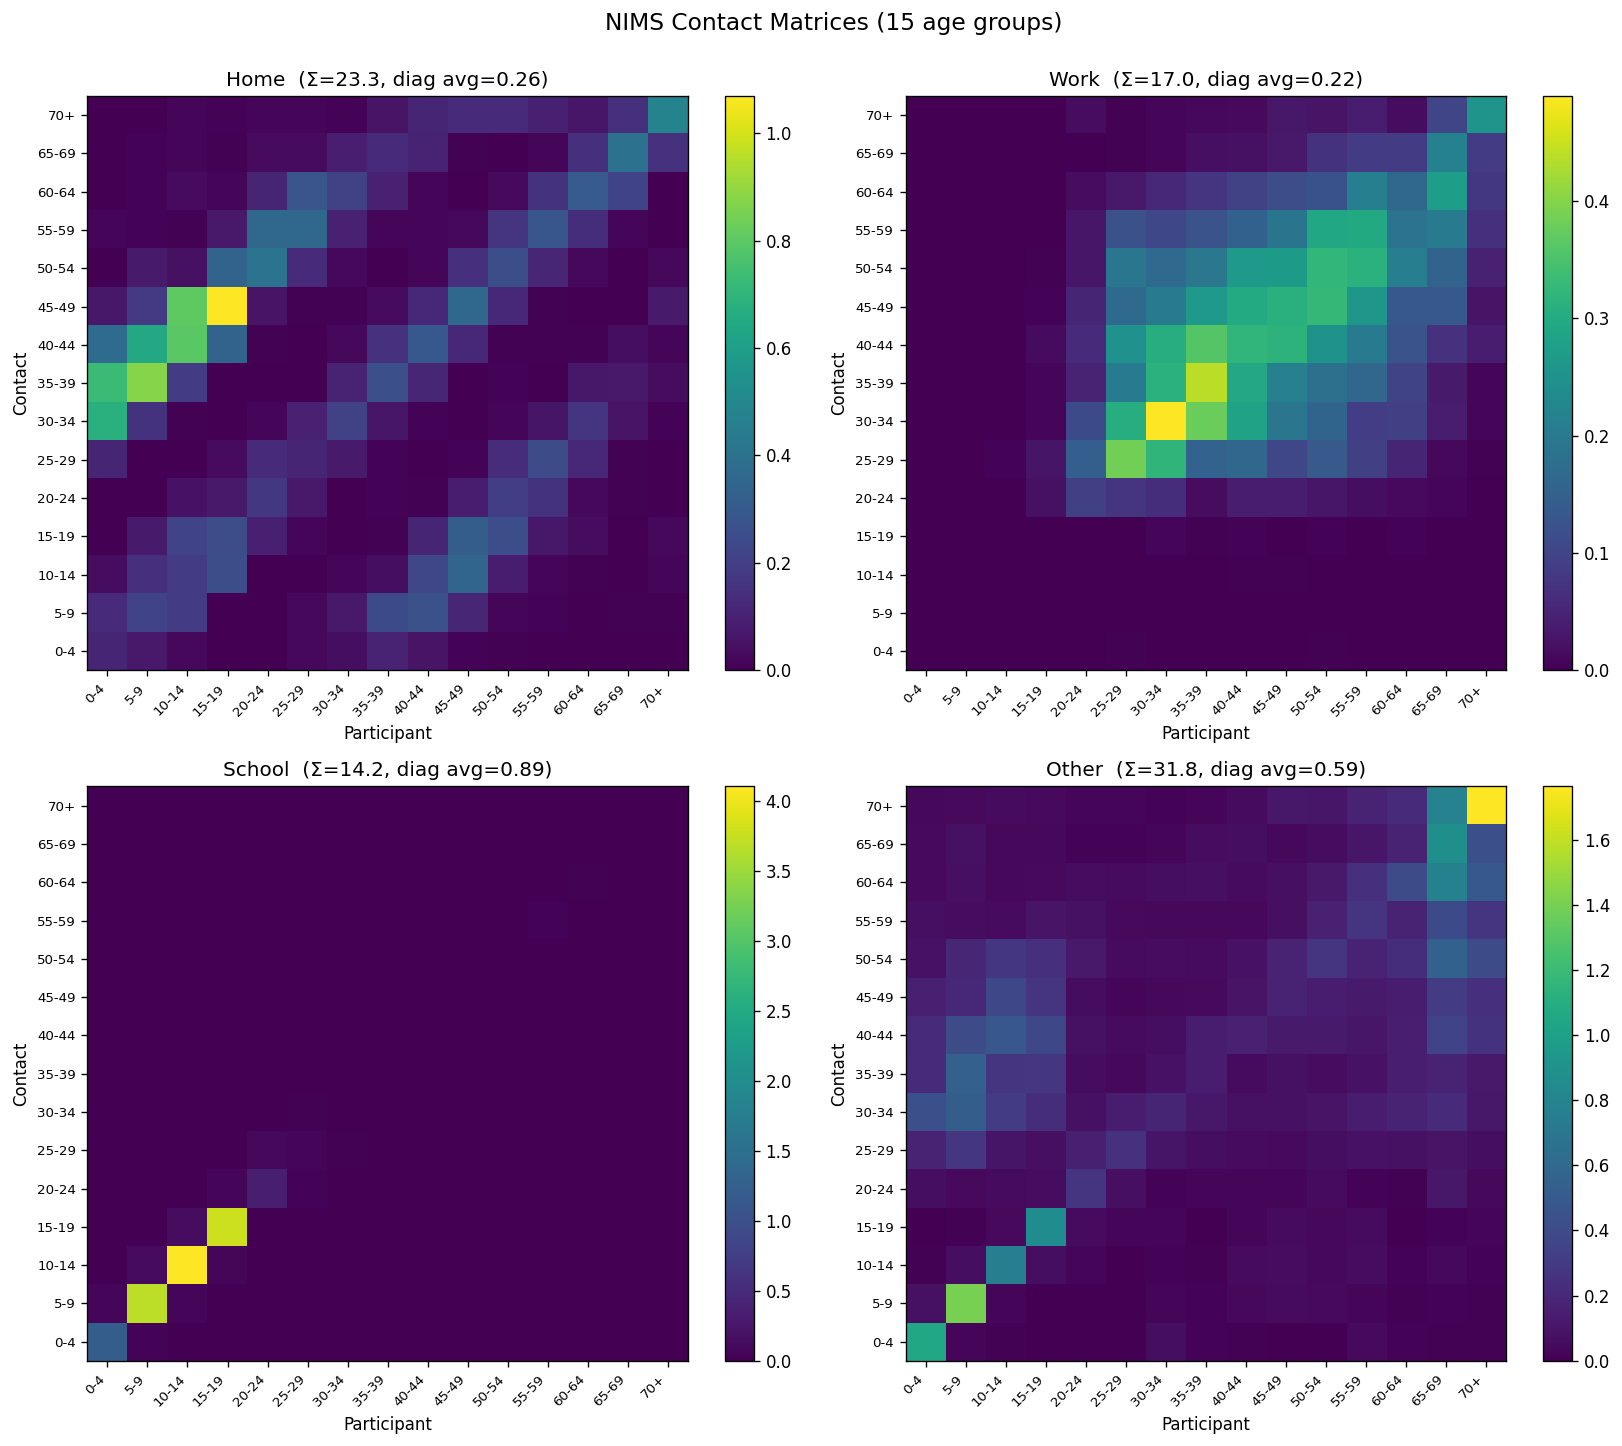

In [5]:
result = load_contact_matrices()
labels = result["age_labels"]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
settings = [("C_home", "Home"), ("C_work", "Work"), ("C_school", "School"), ("C_other", "Other")]

for ax, (key, title) in zip(axes.flat, settings):
    M = result[key]
    im = ax.imshow(M, origin="lower", cmap="viridis", aspect="auto")
    ax.set_xticks(range(15))
    ax.set_yticks(range(15))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Participant")
    ax.set_ylabel("Contact")
    ax.set_title(f"{title}  (Σ={M.sum():.1f}, diag avg={np.diag(M).mean():.2f})")
    plt.colorbar(im, ax=ax)

plt.suptitle("NIMS Contact Matrices (15 age groups)", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(OUT_DIR / "03_contact_matrices.png", dpi=120)
plt.show()

C(weekday_school)    Σ = 86.31
C(vacation_weekday)  Σ = 80.42
C(weekend)           Σ = 71.77
C(school closure)    Σ = 72.07

학교 폐쇄만 효과 (work/home/other 유지): -14.24
전체 주말 효과 (school+work 감소 + home/other 증가): -14.53


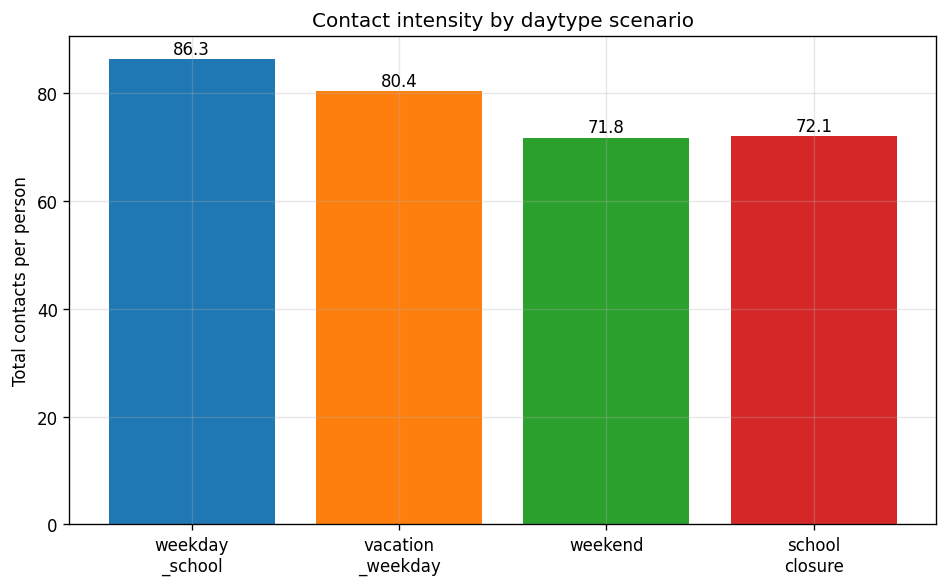

In [6]:
C_weekday = get_contact_matrix(result, daytype="weekday_school")
C_vacation = get_contact_matrix(result, daytype="vacation_weekday")
C_weekend = get_contact_matrix(result, daytype="weekend")

# 학교 폐쇄만 (work/home/other 그대로, school만 0)
C_school_closed = get_contact_matrix(
    result,
    daytype="weekday_school",
    lambdas={"home": 1.0, "work": 1.0, "school": 0.0, "other": 1.0},
)

print(f"C(weekday_school)    Σ = {C_weekday.sum():.2f}")
print(f"C(vacation_weekday)  Σ = {C_vacation.sum():.2f}")
print(f"C(weekend)           Σ = {C_weekend.sum():.2f}")
print(f"C(school closure)    Σ = {C_school_closed.sum():.2f}")
print()
print(f"학교 폐쇄만 효과 (work/home/other 유지): -{C_weekday.sum() - C_school_closed.sum():.2f}")
print(f"전체 주말 효과 (school+work 감소 + home/other 증가): -{C_weekday.sum() - C_weekend.sum():.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
daytypes = ["weekday\n_school", "vacation\n_weekday", "weekend", "school\nclosure"]
sums = [C_weekday.sum(), C_vacation.sum(), C_weekend.sum(), C_school_closed.sum()]
ax.bar(daytypes, sums, color=["C0", "C1", "C2", "C3"])
for i, v in enumerate(sums):
    ax.text(i, v + 1, f"{v:.1f}", ha="center")
ax.set_ylabel("Total contacts per person")
ax.set_title("Contact intensity by daytype scenario")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "04_contact_by_daytype.png", dpi=120)
plt.show()

## 4. Calendar — Daytype

- 4 daytype: `weekday_school`, `vacation_weekday`, `weekend`, `holiday`
- 학사(단순화): 학기 3/1~7/20, 8/20~12/20  /  방학 7/21~8/19, 12/21~2/28
- 우선순위: **holiday > weekend > weekday_school / vacation_weekday**

연도별 daytype 분포:
shape: (6, 5)
┌──────┬─────────┬──────────────────┬────────────────┬─────────┐
│ year ┆ holiday ┆ vacation_weekday ┆ weekday_school ┆ weekend │
│ ---  ┆ ---     ┆ ---              ┆ ---            ┆ ---     │
│ str  ┆ u32     ┆ u32              ┆ u32            ┆ u32     │
╞══════╪═════════╪══════════════════╪════════════════╪═════════╡
│ 2018 ┆ 18      ┆ 64               ┆ 182            ┆ 101     │
│ 2019 ┆ 16      ┆ 65               ┆ 183            ┆ 101     │
│ 2020 ┆ 17      ┆ 69               ┆ 182            ┆ 98      │
│ 2021 ┆ 18      ┆ 68               ┆ 181            ┆ 98      │
│ 2022 ┆ 19      ┆ 67               ┆ 180            ┆ 99      │
│ 2023 ┆ 18      ┆ 66               ┆ 181            ┆ 100     │
└──────┴─────────┴──────────────────┴────────────────┴─────────┘


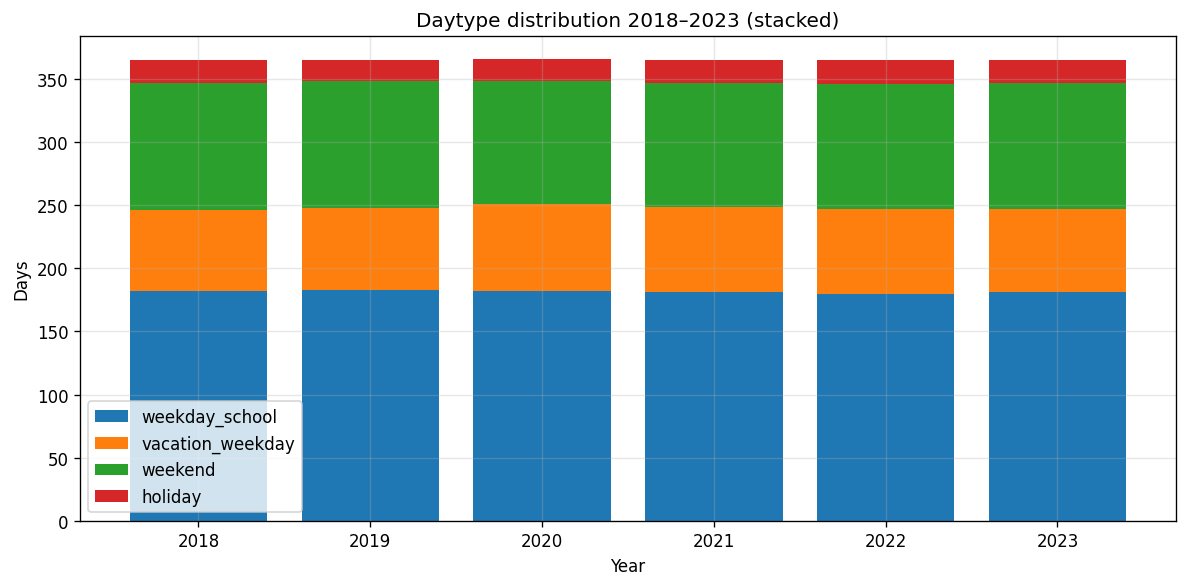

In [7]:
df_cal = get_daytype_for_range(20180101, 20231231)
df_cal = df_cal.with_columns(pl.col("date").cast(pl.Utf8).str.slice(0, 4).alias("year"))

yearly = df_cal.group_by(["year", "daytype"]).agg(pl.len()).sort(["year", "daytype"])

print("연도별 daytype 분포:")
print(yearly.pivot(values="len", index="year", on="daytype"))

years = sorted(df_cal["year"].unique().to_list())
daytypes_list = ["weekday_school", "vacation_weekday", "weekend", "holiday"]
colors = {"weekday_school": "C0", "vacation_weekday": "C1", "weekend": "C2", "holiday": "C3"}

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(years))
for dt in daytypes_list:
    vals = []
    for y in years:
        v = yearly.filter((pl.col("year") == y) & (pl.col("daytype") == dt))
        vals.append(v["len"][0] if len(v) > 0 else 0)
    ax.bar(years, vals, bottom=bottom, label=dt, color=colors[dt])
    bottom += np.array(vals)

ax.set_xlabel("Year")
ax.set_ylabel("Days")
ax.set_title("Daytype distribution 2018–2023 (stacked)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "05_daytype_distribution.png", dpi=120)
plt.show()

## 5. ILI — Calibration target

- 출처: 질병관리청 인플루엔자 표본감시 (감염병포털)
- 5절기 (2018-2019 ~ 2022-2023), 주별 분율 (per 1000 outpatients)
- 시즌 정의: ISO week 36 ~ 다음해 ISO week 35
  - 일반 시즌 52주, **2020-2021만 53주** (2020년이 ISO 53주)
- 한계: 시도별/연령별 미공개

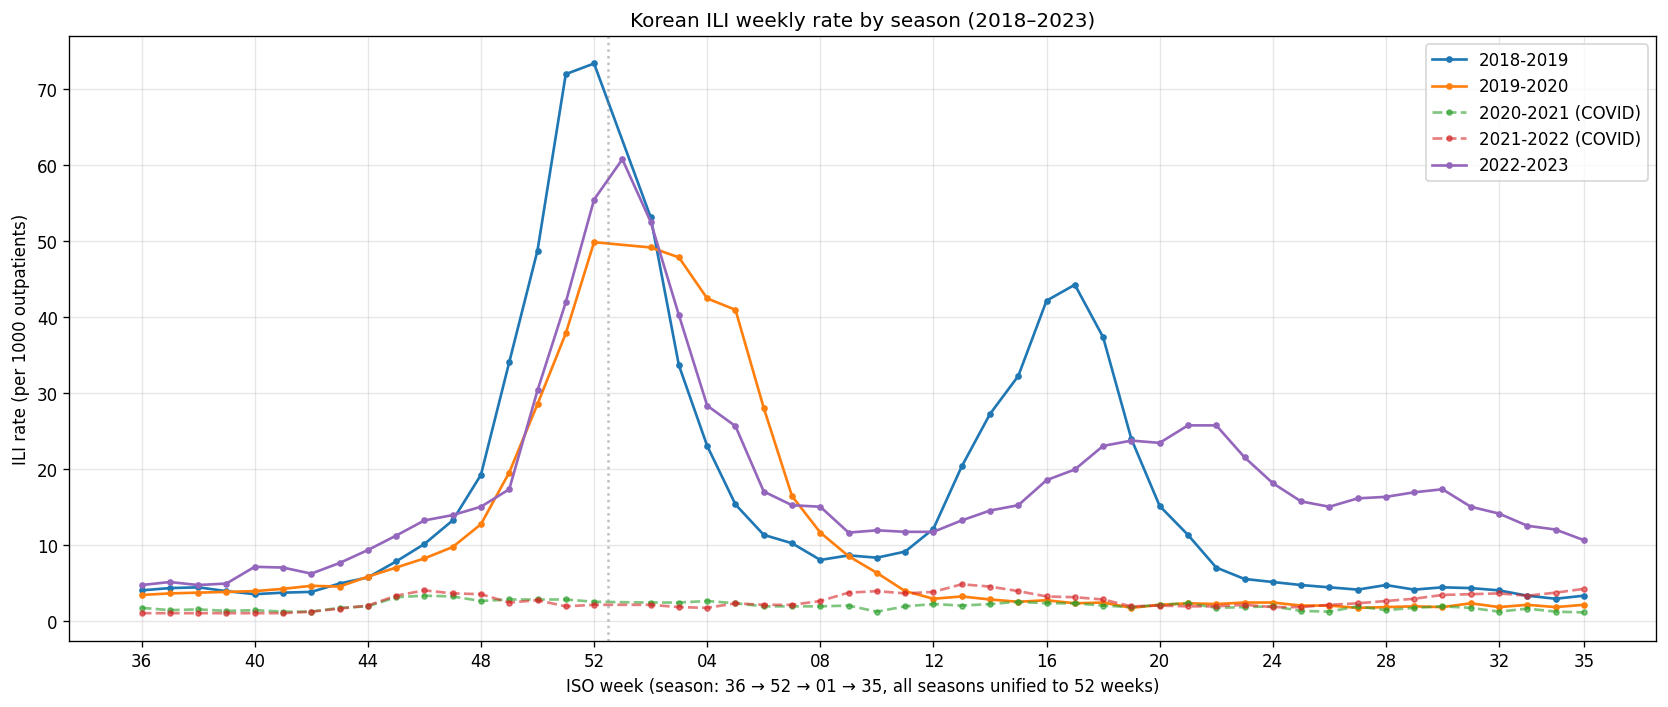

결측 위치 (week_in_season 17 = 다음해 ISO 1주차 부근, 4개 시즌):
shape: (4, 2)
┌───────────┬─────────────────────┐
│ season    ┆ nan_weeks_in_season │
│ ---       ┆ ---                 │
│ str       ┆ list[i32]           │
╞═══════════╪═════════════════════╡
│ 2018-2019 ┆ [17]                │
│ 2019-2020 ┆ [17]                │
│ 2020-2021 ┆ [17]                │
│ 2021-2022 ┆ [17]                │
└───────────┴─────────────────────┘

시즌별 통계 (valid weeks만, 52주 통일):
shape: (5, 5)
┌───────────┬───────────┬──────┬─────┬──────────────┐
│ season    ┆ mean      ┆ max  ┆ min ┆ nan_in_valid │
│ ---       ┆ ---       ┆ ---  ┆ --- ┆ ---          │
│ str       ┆ f64       ┆ f64  ┆ f64 ┆ u32          │
╞═══════════╪═══════════╪══════╪═════╪══════════════╡
│ 2018-2019 ┆ NaN       ┆ 73.3 ┆ 2.9 ┆ 1            │
│ 2019-2020 ┆ NaN       ┆ 49.8 ┆ 1.7 ┆ 1            │
│ 2020-2021 ┆ NaN       ┆ 3.3  ┆ 1.1 ┆ 1            │
│ 2021-2022 ┆ NaN       ┆ 4.8  ┆ 1.0 ┆ 1            │
│ 2022-2023 ┆ 18.463462 ┆ 60.7 ┆ 4.7 ┆ 0   

In [8]:
df_ili = load_ili_seasons()

fig, ax = plt.subplots(figsize=(14, 6))
seasons = ["2018-2019", "2019-2020", "2020-2021", "2021-2022", "2022-2023"]
covid_seasons = {"2020-2021", "2021-2022"}

for season in seasons:
    sub = (
        df_ili.filter((pl.col("season") == season) & pl.col("is_valid_week"))
        .sort("week_in_season")
        .drop_nans("ili_rate")  # 결측 주(주로 week_in_season=17)는 건너뛰어 선이 끊기지 않게
    )
    is_covid = season in covid_seasons
    ax.plot(
        sub["week_in_season"],
        sub["ili_rate"],
        label=season + (" (COVID)" if is_covid else ""),
        linestyle="--" if is_covid else "-",
        alpha=0.6 if is_covid else 1.0,
        marker="o",
        markersize=3,
        lw=1.6,
    )

# x-axis tick labels show actual ISO week numbers (36..52 then 1..35)
x_ticks = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 51]
x_labels = []
for t in x_ticks:
    iso = 36 + t
    if iso > 52:
        iso = iso - 52
    x_labels.append(f"{iso:02d}")
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.axvline(16.5, color="grey", ls=":", alpha=0.5)  # year boundary (ISO 52 → 1)

ax.set_xlabel("ISO week (season: 36 → 52 → 01 → 35, all seasons unified to 52 weeks)")
ax.set_ylabel("ILI rate (per 1000 outpatients)")
ax.set_title("Korean ILI weekly rate by season (2018–2023)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "06_ili_seasons.png", dpi=120)
plt.show()

# 결측 점검 (시즌별)
nan_summary = (
    df_ili.filter(pl.col("is_valid_week") & pl.col("ili_rate").is_nan())
    .group_by("season")
    .agg(pl.col("week_in_season").alias("nan_weeks_in_season"))
    .sort("season")
)
print("결측 위치 (week_in_season 17 = 다음해 ISO 1주차 부근, 4개 시즌):")
print(nan_summary)

summary = (
    df_ili.filter(pl.col("is_valid_week"))
    .group_by("season")
    .agg(
        pl.col("ili_rate").mean().alias("mean"),
        pl.col("ili_rate").max().alias("max"),
        pl.col("ili_rate").min().alias("min"),
        pl.col("ili_rate").is_nan().sum().alias("nan_in_valid"),
    )
    .sort("season")
)
print("\n시즌별 통계 (valid weeks만, 52주 통일):")
print(summary)

## 6. 데이터 → 모델 input 흐름

본 프로젝트는 5종 데이터를 정제하고 표준 로더를 제공한다.  
다음 프로젝트(`kt_epimodel`)에서 metapop 인플루엔자 모델 input으로 사용:

| 데이터 | 출처 | 형태 | 모델 변수 / 용도 |
|---|---|---|---|
| 인구 (15군) | 주민등록 (MOIS) | 1,148 × 15 | `N^a_i` (분모) |
| Mobility π | KT 통신 | 1,154 × 1,154 × 7 × 24 | `π^a_ji(t)` (FOI 가중치) |
| Contact C | NIMS 설문 | 4 × 15 × 15 | `C^ab(t)` (FOI 핵심) |
| Calendar | 학사 + 공휴일 | daytype/day | `λ_setting(t)` 결정 |
| ILI | 질병청 | 5 시즌 × ~52 주 | calibration target |

## 7. 미해결 결정사항 (다음 프로젝트로 이월)

- `λ_home`, `λ_work`, `λ_other` 시간 가변 정확값 (NIMS notebook 04/06 확인)
- NIMS contact 절대값 보정 방법 (β 흡수 vs 외부 scaling)
- ILI 시도별/연령별 raw data 협조 요청 (질병청)
- NIMS 설문 Q4 코드 8 / 9 / 9997 의미
- KT 검출률 Phase 4 실측 (인구 vs KT 출발지 합)
- 7군 → 15군 mobility 분배 방식 (인구 비례? age-specific commute rate?)
- 코로나 시기 lockdown 별도 λ scenario 정의

## 결론

`kt_data` 프로젝트 완료. 정제 데이터(LivePOP 72개월 / Movement 72개월) + 표준 로더 5종 + 단위 테스트(60+ 통과) 제공.

**다음**: `kt_epimodel` 프로젝트에서
- Metapop SEIR 모델 구축 (행정동 × 연령군)
- KT mobility · NIMS contact · daytype λ(t) 결합
- ILI calibration → 베이스 시뮬레이션 보정
- sick-leave 정책 ICER 분석